In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.manifold import TSNE
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import kurtosis, skew
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.spatial.distance import cdist

In [2]:
save_path = "../plots/comparison/RQ1/"

### Load datasets

In [3]:
root_dir = "../../saved_models/STCRL_transfer_learning/embeddings/"
monkeypr_data_path = root_dir + "embedded_trajectories_monkey.csv"
ucpmp_data_path = root_dir + "embedded_trajectories_ucpmp.csv"
msl_data_path = root_dir + "embedded_trajectories_msl.csv"
# Load the data
monkeypr_df = pd.read_csv(monkeypr_data_path)
ucpmp_df = pd.read_csv(ucpmp_data_path)
msl_df = pd.read_csv(msl_data_path)


In [4]:
monkeypr_df['task_label'] = "Reaching"
monkeypr_df.columns = ['exp_type', 'session_no', 'trial_no', 'Time', 'HandPos', 'TargetPos',
       'time_diff_ms', 'path', 'target_position', 'normalized_trajectory',
       'Cohort', 'completion_time', 'rmsd', 'is_success',
       'trajectory_embedding_default', 'exploration_score',
       'exploitation_score', 'exploration_exploitation_ratio', 'task_label']
# Keep only (exp_type, session_no) groups that have exactly 48 unique trials
trials_per_session = (
    monkeypr_df.groupby(['exp_type', 'session_no'])['trial_no']
    .nunique()
    .reset_index(name='trials_per_session')
    .sort_values(['exp_type', 'session_no'])
)

valid_sessions = trials_per_session.loc[
    trials_per_session["trials_per_session"] == 48, ["exp_type", "session_no"]
]

monkeypr_df = monkeypr_df.merge(valid_sessions, on=["exp_type", "session_no"], how="inner")
monkeypr_df['completion_time'] = monkeypr_df['completion_time']/1000.0
print(monkeypr_df.columns)
print(monkeypr_df.shape)
monkeypr_df.head()

Index(['exp_type', 'session_no', 'trial_no', 'Time', 'HandPos', 'TargetPos',
       'time_diff_ms', 'path', 'target_position', 'normalized_trajectory',
       'Cohort', 'completion_time', 'rmsd', 'is_success',
       'trajectory_embedding_default', 'exploration_score',
       'exploitation_score', 'exploration_exploitation_ratio', 'task_label'],
      dtype='object')
(18432, 19)


,exp_type,session_no,trial_no,Time,HandPos,TargetPos,time_diff_ms,path,target_position,normalized_trajectory,Cohort,completion_time,rmsd,is_success,trajectory_embedding_default,exploration_score,exploitation_score,exploration_exploitation_ratio,task_label
0,Scott_2001_e1,1,1,[0.006;0.016;0.026;0.036;0.046;0.056;0.066;0.0...,[-13.166 280.695;-13.3428 280.618;-13.5578 280...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 6. 16. 26. 36. 46. 56. 66. 7...,"[(-13.166, 280.695), (-13.3428, 280.618), (-13...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 6.00000000e...,Monkey,4.40,28.846063,0,[ 2.746458 1.3643794 -0.11187054 -1.244191...,0.087047,0.000000,8.704692,Reaching
1,Scott_2001_e1,1,2,[0.052;0.062;0.072;0.082;0.092;0.102;0.112;0.1...,[-18.7382 283.289;-19.4048 282.418;-19.9414 28...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 52. 62. 72. 82. 92. 102. 112. 12...,"[(-18.7382, 283.289), (-19.4048, 282.418), (-1...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 5.20000000e...,Monkey,4.63,32.107887,0,[ 2.6919947 1.3441939 -0.08182078 -1.208788...,0.052366,0.641779,0.080343,Reaching
2,Scott_2001_e1,1,3,[1.064;1.074;1.084;1.094;1.104;1.114;1.124;1.1...,[-20.5466 283.837;-20.168 283.326;-19.64 282.8...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[1064. 1074. 1084. 1094. 1104. 1114. 1124. 113...,"[(-20.5466, 283.837), (-20.168, 283.326), (-19...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 1.06400000e...,Monkey,4.55,26.912938,0,[ 1.6539602 0.9195859 0.44686127 -0.457816...,0.247908,0.269935,0.885591,Reaching
3,Scott_2001_e1,1,4,[0.352;0.362;0.372;0.382;0.392;0.402;0.412;0.4...,[-14.548 281.899;-14.9 281.372;-15.251 280.844...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 352. 362. 372. 382. 392. 402. 412. 42...,"[(-14.548, 281.899), (-14.9, 281.372), (-15.25...","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 3.52000000e...,Monkey,3.99,28.657583,0,[ 2.2790565 1.1866221 0.13658434 -0.936977...,0.057048,0.619894,0.090568,Reaching
4,Scott_2001_e1,1,5,[0.046;0.056;0.066;0.076;0.086;0.096;0.106;0.1...,[-20.558 279.653;-20.508 279.572;-20.293 279.5...,[23 320;23 320;23 320;23 320;23 320;23 320;23 ...,[ 46. 56. 66. 76. 86. 96. 106. 11...,"[(-20.558, 279.653), (-20.508, 279.572), (-20....","(23.0, 320.0)",[[ 0.00000000e+00 0.00000000e+00 4.60000000e...,Monkey,3.84,29.393611,0,[ 2.6876135 1.3426018 -0.07927531 -1.206956...,0.070156,0.568284,0.121318,Reaching


In [5]:
monkeypr_df['target_position']

0        (23.0, 320.0)
1        (23.0, 320.0)
2        (23.0, 320.0)
3        (23.0, 320.0)
4        (23.0, 320.0)
             ...      
18427    (48.0, 266.0)
18428    (48.0, 266.0)
18429    (48.0, 266.0)
18430    (48.0, 266.0)
18431    (48.0, 266.0)
Name: target_position, Length: 18432, dtype: object

In [6]:
# Create a new dataframe name as requested
monkeypd_df = monkeypr_df.copy()

# Compute distance from origin (0, 0) to target_position
target_xy = monkeypd_df["target_position"].str.strip("()").str.split(",", expand=True).astype(float)
monkeypd_df["actual_dist"] = np.sqrt(target_xy[0]**2 + target_xy[1]**2)

monkeypd_df[["target_position", "actual_dist"]].head()

,target_position,actual_dist
0,"(23.0, 320.0)",320.825498
1,"(23.0, 320.0)",320.825498
2,"(23.0, 320.0)",320.825498
3,"(23.0, 320.0)",320.825498
4,"(23.0, 320.0)",320.825498


In [7]:
monkeypd_df.columns

Index(['exp_type', 'session_no', 'trial_no', 'Time', 'HandPos', 'TargetPos',
       'time_diff_ms', 'path', 'target_position', 'normalized_trajectory',
       'Cohort', 'completion_time', 'rmsd', 'is_success',
       'trajectory_embedding_default', 'exploration_score',
       'exploitation_score', 'exploration_exploitation_ratio', 'task_label',
       'actual_dist'],
      dtype='object')

In [8]:
ucpmp_df['task_label'] = "Reaching"
print(ucpmp_df.columns)
print(ucpmp_df.shape)
ucpmp_df['completion_time']

Index(['participant_id', 'Age', 'day', 'trial_hand', 'session_no', 'planet',
       'start_time', 'end_time', 'target_pos', 'planet_pos', 'path',
       'time_string', 'time_diff_ms', 'completion_time', 'movement_dist',
       'trial_start_time', 'trial_no', 'target_point_x', 'target_point_y',
       'start_point_x', 'start_point_y', 'Cohort', 'actual_dist', 'rmsd',
       'block_no', 'distances', 'normalized_trajectory',
       'original_target_angle', 'rotation_angle', 'original_end_vector',
       'is_success', 'trajectory_embedding_default', 'task_type',
       'exploration_score', 'exploitation_score', 'novelty',
       'avg_similarity_to_window', 'max_similarity_to_window', 'trial_seq',
       'task_label', 'exploration_exploitation_ratio', 'learning_rate',
       'strategy_stability'],
      dtype='object')
(4800, 43)


0       17.272
1        4.419
2        2.743
3        2.284
4        7.588
         ...  
4795     0.959
4796     1.109
4797     1.017
4798     0.976
4799     1.033
Name: completion_time, Length: 4800, dtype: float64

In [9]:
print(msl_df.columns)
msl_df.head()

Index(['participant_id', 'session_no', 'task_type', 'trial_no', 'day', 'block',
       'start_point_x', 'start_point_y', 'target_point_x', 'target_point_y',
       'start_time', 'end_time', 'quadrant', 'is_success', 'actual_dist',
       'movement_dist', 'completion_time', 'path', 'time_string',
       'time_diff_ms', 'Age', 'Cohort', 'Gestational_Age',
       'mabc_total_test_score', 'mabc_standard_score', 'mabc_percentile',
       'distances', 'rmsd', 'normalized_trajectory',
       'trajectory_embedding_completion_time',
       'trajectory_embedding_task_type', 'trajectory_embedding_rmsd',
       'trajectory_embedding_success',
       'trajectory_embedding_within_between_subject',
       'trajectory_embedding_multi_loss', 'exploration_score',
       'exploitation_score', 'novelty', 'avg_similarity_to_window',
       'max_similarity_to_window', 'trial_seq', 'task_label',
       'exploration_exploitation_ratio', 'learning_rate',
       'strategy_stability'],
      dtype='object')


,participant_id,session_no,task_type,trial_no,day,block,start_point_x,start_point_y,target_point_x,target_point_y,...,exploration_score,exploitation_score,novelty,avg_similarity_to_window,max_similarity_to_window,trial_seq,task_label,exploration_exploitation_ratio,learning_rate,strategy_stability
0,0,1,0,1,Day-1,Block-1,0,0,451.220748,-453.255370,...,0.048183,0.000000,1.000000,0.000000,0.000000,1.0,Unimanual,4.818315,NaN,NaN
1,0,1,0,2,Day-1,Block-1,0,0,-523.109406,-447.873534,...,0.233841,0.170576,4.865830,0.170479,0.170479,2.0,Unimanual,1.294971,NaN,NaN
2,0,1,0,3,Day-1,Block-1,0,0,557.574475,325.309867,...,0.123192,0.280172,2.571275,0.213571,0.280012,3.0,Unimanual,0.424550,NaN,NaN
3,0,1,0,4,Day-1,Block-1,0,0,476.961663,216.321327,...,0.100758,0.321796,2.109330,0.265693,0.321613,4.0,Unimanual,0.303676,NaN,NaN
4,0,1,0,5,Day-1,Block-1,0,0,-497.485877,-249.059722,...,0.091640,0.342180,1.924110,0.267748,0.341984,5.0,Unimanual,0.260208,NaN,NaN


In [10]:
msl_df['completion_time']

0        10.528
1        10.982
2        10.925
3        10.994
4        11.006
          ...  
16315    10.979
16316     1.278
16317     9.964
16318     6.653
16319     4.642
Name: completion_time, Length: 16320, dtype: float64

### RQ1: How effectively does the E-E framework, particularly the micro-level E-E ratio, quantify motor performance compared to traditional macro-level parameters such as speed and accuracy?

**Definitions used in this RQ1 analysis**
- **Micro metric:** `exploration_exploitation_ratio` (E–E ratio).
- **Macro metrics:**
  - **Speed:** `speed = actual_dist / completion_time`
  - **Accuracy (path efficiency):** `rmsd_norm = rmsd / actual_dist` (lower is better)
- **Learning comparisons:**
  - Monkey: Session 1 vs last session (within each experiment).
  - UCPMP: Session 1 vs Session 2 (within each participant).
  - MSL: Session 1 vs Session 5 (within each participant × task_type).
- Notes: `completion_time` is coerced to seconds if it looks like milliseconds (heuristic based on median).

## RQ1 (MSL + UCPMP only): t-tests + sequential plots
This section uses only:
- **MSL** (Unimaual only): compare **TERM vs PRETERM**
- **MP**: compare **TD vs UCP**
Metrics: **Speed**, **Accuracy** (`rmsd_norm`), and **Micro** E–E ratio.

,UCPMP_n_units,MSL_n_units
0,50,68


,dataset,metric,group_A,n_A,mean_A,ci95_low_A,ci95_high_A,mean±95CI_A,group_B,n_B,mean_B,ci95_low_B,ci95_high_B,mean±95CI_B,t,p,cohen_d
0,UCPMP,speed,TD,40,508.091615,472.972773,543.210458,"508.1 [473, 543.2]",UCP,10,330.638817,230.390346,430.887288,"330.6 [230.4, 430.9]",3.728369,0.002918,1.528432
1,UCPMP,rmsd_norm,TD,40,0.053740,0.043601,0.063879,"0.05374 [0.0436, 0.06388]",UCP,10,0.070083,0.055044,0.085123,"0.07008 [0.05504, 0.08512]",-1.962829,0.063310,-0.544932
2,UCPMP,exploration_exploitation_ratio,TD,40,0.123079,0.099601,0.146557,"0.1231 [0.0996, 0.1466]",UCP,10,0.283508,0.144173,0.422843,"0.2835 [0.1442, 0.4228]",-2.559567,0.029149,-1.496516
3,MSL (Bimanual),speed,TERM,50,99.156438,92.235087,106.077790,"99.16 [92.24, 106.1]",PRETERM,18,94.829289,85.259146,104.399433,"94.83 [85.26, 104.4]",0.759760,0.452101,0.186949
4,MSL (Bimanual),rmsd_norm,TERM,50,0.398972,0.371389,0.426556,"0.399 [0.3714, 0.4266]",PRETERM,18,0.444680,0.401425,0.487934,"0.4447 [0.4014, 0.4879]",-1.852569,0.072817,-0.483342
5,MSL (Bimanual),exploration_exploitation_ratio,TERM,50,0.286146,0.262532,0.309760,"0.2861 [0.2625, 0.3098]",PRETERM,18,0.339377,0.294231,0.384523,"0.3394 [0.2942, 0.3845]",-2.180513,0.037807,-0.625232


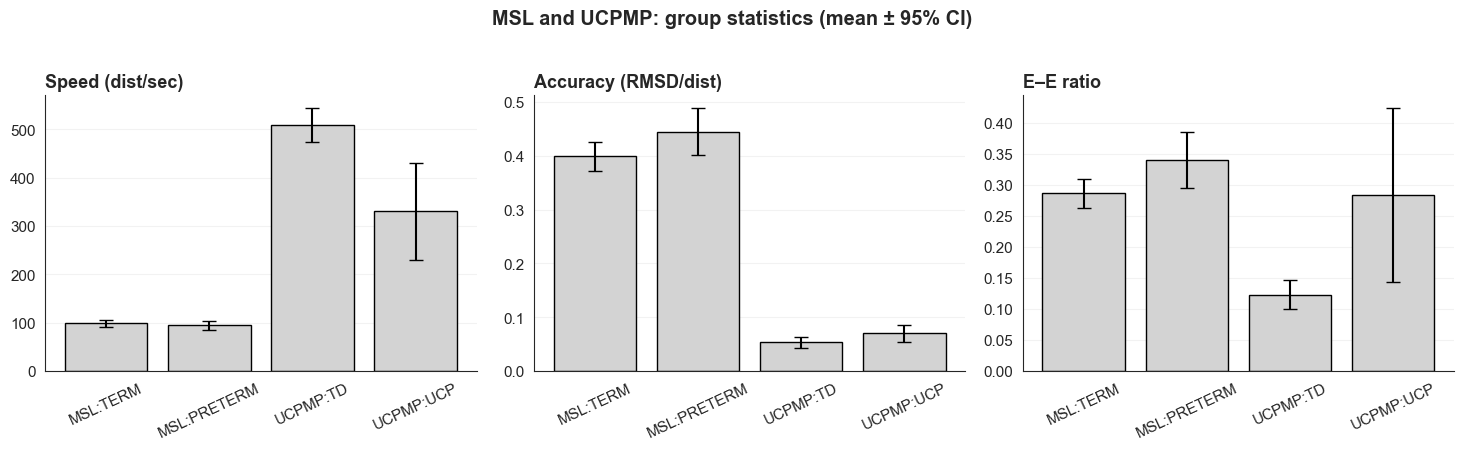

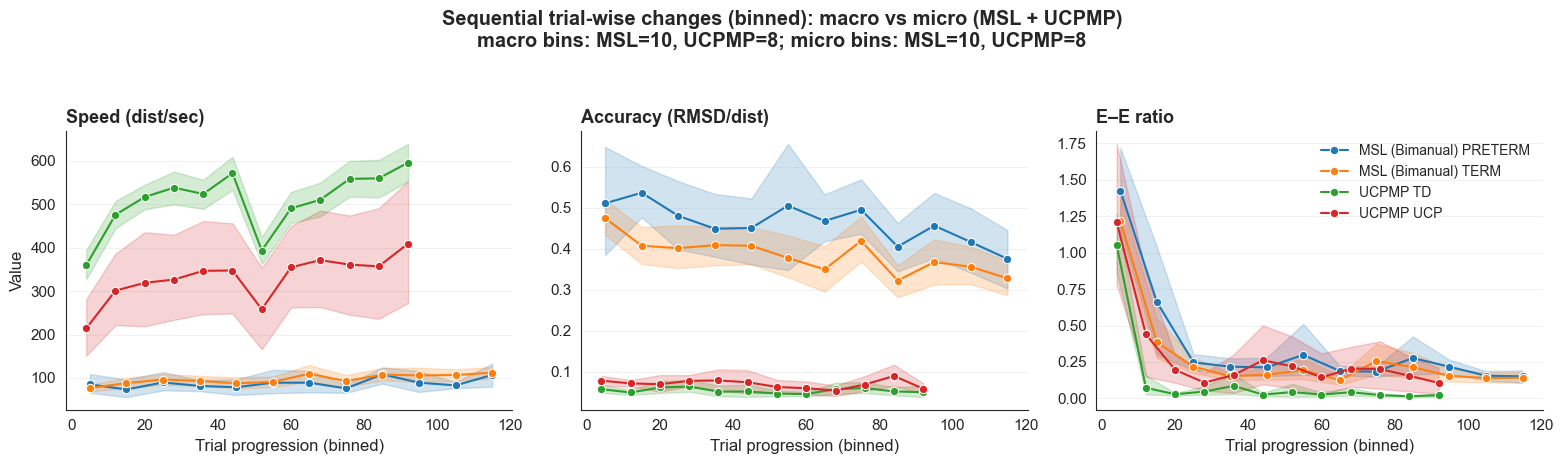

In [20]:
# 1) t-tests (MSL Bimanual: TERM vs PRETERM) + (UCPMP: TD vs UCP)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

sns.set_style("white")

MICRO_COL = "exploration_exploitation_ratio"
TIME_COL = "completion_time"
RMSD_COL = "rmsd"
DIST_COL = "actual_dist"

def _find_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _rank_sessions(s: pd.Series) -> pd.Series:
    uniq = pd.Series(pd.unique(s))
    uniq_num = pd.to_numeric(uniq, errors="coerce")
    if uniq_num.notna().any():
        order = uniq.iloc[np.argsort(uniq_num.fillna(np.inf).values)]
    else:
        order = uniq.astype(str).sort_values()
    mapping = {val: i + 1 for i, val in enumerate(order)}
    return s.map(mapping)

def _ensure_seconds(df: pd.DataFrame, time_col: str = TIME_COL) -> pd.DataFrame:
    df = df.copy()
    if time_col not in df.columns:
        return df
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    med = float(df[time_col].median(skipna=True)) if df[time_col].notna().any() else np.nan
    # If median looks like milliseconds, convert to seconds
    if np.isfinite(med) and med > 50:
        df[time_col] = df[time_col] / 1000.0
    return df

def _ensure_actual_dist(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if DIST_COL in df.columns:
        df[DIST_COL] = pd.to_numeric(df[DIST_COL], errors="coerce")
    return df

def _add_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in [MICRO_COL, TIME_COL, RMSD_COL, DIST_COL]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")
    df["speed"] = np.where(
        df[DIST_COL].notna() & df[TIME_COL].notna() & (df[TIME_COL] > 0),
        df[DIST_COL] / df[TIME_COL],
        np.nan,
    )
    df["rmsd_norm"] = np.where(
        df[RMSD_COL].notna() & df[DIST_COL].notna() & (df[DIST_COL] > 0),
        df[RMSD_COL] / df[DIST_COL],
        np.nan,
    )
    return df

def _ci95_t(x: pd.Series):
    x = pd.to_numeric(pd.Series(x), errors="coerce").dropna().astype(float)
    n = int(x.shape[0])
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(x.mean())
    if n < 2:
        return mean, np.nan, np.nan, n
    sem = stats.sem(x, nan_policy="omit")
    h = stats.t.ppf(0.975, df=n - 1) * sem
    return mean, mean - float(h), mean + float(h), n

def _fmt_mean_ci(mean, lo, hi):
    if not (np.isfinite(mean) and np.isfinite(lo) and np.isfinite(hi)):
        return "NA"
    return f"{mean:.4g} [{lo:.4g}, {hi:.4g}]"

def _welch_ttest(x: pd.Series, y: pd.Series):
    a = pd.to_numeric(pd.Series(x), errors="coerce").dropna().astype(float)
    b = pd.to_numeric(pd.Series(y), errors="coerce").dropna().astype(float)
    n1, n2 = int(a.shape[0]), int(b.shape[0])
    if n1 < 2 or n2 < 2:
        return {"t": np.nan, "p": np.nan, "n1": n1, "n2": n2, "cohen_d": np.nan}
    t, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
    s1, s2 = float(a.std(ddof=1)), float(b.std(ddof=1))
    sp = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / (n1 + n2 - 2)) if (n1 + n2 - 2) > 0 else np.nan
    d = float((a.mean() - b.mean()) / sp) if np.isfinite(sp) and sp > 0 else np.nan
    return {"t": float(t), "p": float(p), "n1": n1, "n2": n2, "cohen_d": d}

def _summarize_by_group(df_units: pd.DataFrame, group_col: str, metric_cols):
    rows = []
    for g, gdf in df_units.groupby(group_col):
        for m in metric_cols:
            mean, lo, hi, n = _ci95_t(gdf[m])
            rows.append({"group": str(g), "metric": m, "mean": mean, "ci_low": lo, "ci_high": hi, "n_units": n, "mean_95ci": _fmt_mean_ci(mean, lo, hi)})
    return pd.DataFrame(rows)

# ------------------
# Prepare UCPMP units
# ------------------
if "ucpmp_df" not in globals():
    raise NameError("ucpmp_df not found. Run the load cells above.")

uc = ucpmp_df.copy()
uc = _ensure_seconds(uc)
uc = _ensure_actual_dist(uc)
uc = _add_metrics(uc)

uc_cohort_col = _find_col(uc, ["Cohort", "cohort", "GROUP", "Group", "group"])
if uc_cohort_col is None:
    raise KeyError("Could not find cohort column in ucpmp_df")
uc["cohort_norm"] = (
    uc[uc_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"UCPMP": "UCP", "UCP": "UCP", "TD": "TD", "TDC": "TD", "CONTROL": "TD", "TYPICAL": "TD"})
 )
uc = uc[uc["cohort_norm"].isin(["TD", "UCP"])].copy()

if "participant_id" not in uc.columns:
    raise KeyError("ucpmp_df must have participant_id")
uc["unit_id"] = uc["participant_id"].astype(str)

metric_cols = ["speed", "rmsd_norm", MICRO_COL]
uc_units = (
    uc.groupby(["unit_id", "cohort_norm"], as_index=False)[metric_cols]
    .mean()
    .rename(columns={"cohort_norm": "group"})
)
uc_units["group"] = uc_units["group"].astype(str).str.upper()

# ----------------
# Prepare MSL units
# ----------------
if "msl_df" not in globals():
    raise NameError("msl_df not found. Run the load cells above.")

ms = msl_df.copy()
ms = _ensure_seconds(ms)
ms = _ensure_actual_dist(ms)
ms = _add_metrics(ms)

ms_cohort_col = _find_col(ms, ["Cohort", "cohort", "GROUP", "Group", "group"])
if ms_cohort_col is None:
    raise KeyError("Could not find cohort column in msl_df")
ms["cohort_norm"] = (
    ms[ms_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"TERM": "TERM", "PRETERM": "PRETERM", "PRE-TERM": "PRETERM", "PT": "PRETERM"})
 )
ms = ms[ms["cohort_norm"].isin(["TERM", "PRETERM"])].copy()

task_col = _find_col(ms, ["task_type", "task", "Task"])
if task_col is None:
    raise KeyError("msl_df must include task_type")
ms["task_type"] = pd.to_numeric(ms[task_col], errors="coerce")
ms = ms[ms["task_type"] == 1].copy()  # Bimanual only

if "participant_id" not in ms.columns:
    raise KeyError("msl_df must have participant_id")
ms["unit_id"] = ms["participant_id"].astype(str)

ms_units = (
    ms.groupby(["unit_id", "cohort_norm"], as_index=False)[metric_cols]
    .mean()
    .rename(columns={"cohort_norm": "group"})
)
ms_units["group"] = ms_units["group"].astype(str).str.upper()

display(pd.DataFrame({"UCPMP_n_units": [uc_units['unit_id'].nunique()], "MSL_n_units": [ms_units['unit_id'].nunique()]}))

# -------------------
# 1) t-test significance + mean±95%CI columns
# -------------------
def _ttest_table(df_units: pd.DataFrame, dataset: str, group_a: str, group_b: str, metrics: list) -> pd.DataFrame:
    rows = []
    for m in metrics:
        a = df_units.loc[df_units["group"] == group_a, m]
        b = df_units.loc[df_units["group"] == group_b, m]
        ma, la, ha, na = _ci95_t(a)
        mb, lb, hb, nb = _ci95_t(b)
        test = _welch_ttest(a, b)
        rows.append({
            "dataset": dataset,
            "metric": m,
            "group_A": group_a,
            "n_A": na,
            "mean_A": ma,
            "ci95_low_A": la,
            "ci95_high_A": ha,
            "mean±95CI_A": _fmt_mean_ci(ma, la, ha),
            "group_B": group_b,
            "n_B": nb,
            "mean_B": mb,
            "ci95_low_B": lb,
            "ci95_high_B": hb,
            "mean±95CI_B": _fmt_mean_ci(mb, lb, hb),
            "t": test["t"],
            "p": test["p"],
            "cohen_d": test["cohen_d"],
        })
    return pd.DataFrame(rows)

ttest_df = pd.concat([
    _ttest_table(uc_units, dataset="UCPMP", group_a="TD", group_b="UCP", metrics=metric_cols),
    _ttest_table(ms_units, dataset="MSL (Bimanual)", group_a="TERM", group_b="PRETERM", metrics=metric_cols),
], ignore_index=True)
display(ttest_df)

# ------------------------------
# 2) Summary stats for plotting
# ------------------------------
uc_sum = _summarize_by_group(uc_units, group_col="group", metric_cols=metric_cols)
uc_sum["dataset"] = "UCPMP"
ms_sum = _summarize_by_group(ms_units, group_col="group", metric_cols=metric_cols)
ms_sum["dataset"] = "MSL (Bimanual)"
sum_df = pd.concat([ms_sum, uc_sum], ignore_index=True)

# ------------------------------
# 3) Plot statistics in one figure
# ------------------------------
label_map = {
    "speed": "Speed (dist/sec)",
    "rmsd_norm": "Accuracy (RMSD/dist)",
    MICRO_COL: "E–E ratio",
}
group_order = ["TERM", "PRETERM", "TD", "UCP"]
plot_df = sum_df.copy()
plot_df["group"] = plot_df["group"].astype(str).str.upper()
plot_df["group"] = plot_df["group"].replace({"PRE-TERM": "PRETERM"})
plot_df["metric_label"] = plot_df["metric"].map(label_map).fillna(plot_df["metric"])
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)
plot_df = plot_df.sort_values(["metric", "group"])

fig, axes = plt.subplots(1, 3, figsize=(14.8, 4.4))
for ax, metric in zip(axes, metric_cols):
    sub = plot_df[plot_df["metric"] == metric].copy()
    # Build x labels that combine dataset + group
    sub["x"] = sub["dataset"].str.replace(" (Bimanual)", "", regex=False) + ":" + sub["group"].astype(str)
    x_order = ["MSL:" + g for g in ["TERM", "PRETERM"]] + ["UCPMP:" + g for g in ["TD", "UCP"]]
    sub["x"] = pd.Categorical(sub["x"], categories=x_order, ordered=True)
    sub = sub.sort_values("x")
    yerr = np.vstack([sub["mean"] - sub["ci_low"], sub["ci_high"] - sub["mean"]])
    ax.bar(sub["x"].astype(str), sub["mean"], yerr=yerr, capsize=5, color="lightgray", edgecolor="black")
    ax.set_title(label_map.get(metric, metric), fontweight="bold", loc="left")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)
fig.suptitle("MSL and UCPMP: group statistics (mean ± 95% CI)", y=1.02, fontweight="bold")
fig.tight_layout()
plt.show()

# ----------------------------------------------------------
# 4) Sequential changes (trial_seq-based; binned)
# ----------------------------------------------------------
# Parameters for experimenting with different window sizes
msl_macro_bin_size = 10
msl_micro_bin_size = 10
ucpmp_macro_bin_size = 8
ucpmp_micro_bin_size = 8

def _build_global_trial_index(
    df: pd.DataFrame,
    unit_col: str,
    session_col: str,
    trial_seq_col: str,
    trials_per_session: int,
    expected_total_trials: int,
 ) -> pd.Series:
    """Return global trial index per unit in [1..expected_total_trials].
    Uses trial_seq directly if it already looks global; otherwise builds it from session_rank + within-session order."""
    d = df[[unit_col, session_col, trial_seq_col]].copy()
    d[trial_seq_col] = pd.to_numeric(d[trial_seq_col], errors="coerce")
    d = d.dropna(subset=[trial_seq_col])
    d[trial_seq_col] = d[trial_seq_col].astype(int)
    # session rank per unit
    d["session_rank"] = d.groupby(unit_col)[session_col].transform(_rank_sessions)
    # detect whether trial_seq is global per unit
    meta = (
        d.groupby(unit_col)[trial_seq_col]
        .agg(max_trial="max", nunique="nunique")
        .reset_index()
    )
    meta["is_global"] = (meta["max_trial"] > trials_per_session) | (meta["nunique"] > trials_per_session)
    d = d.merge(meta[[unit_col, "is_global"]], on=unit_col, how="left")
    # build within-session order when not global
    d = d.sort_values([unit_col, "session_rank", trial_seq_col])
    d["trial_in_session"] = d.groupby([unit_col, "session_rank"]).cumcount() + 1
    d["trial_global"] = np.where(
        d["is_global"],
        d[trial_seq_col],
        (d["session_rank"].astype(int) - 1) * trials_per_session + d["trial_in_session"].astype(int),
    )
    d["trial_global"] = pd.to_numeric(d["trial_global"], errors="coerce")
    # align back to original index order via merge on keys
    out = df[[unit_col, session_col, trial_seq_col]].copy()
    out[trial_seq_col] = pd.to_numeric(out[trial_seq_col], errors="coerce")
    out = out.merge(d[[unit_col, session_col, trial_seq_col, "trial_global"]], on=[unit_col, session_col, trial_seq_col], how="left")
    trial_global = out["trial_global"]
    trial_global = pd.to_numeric(trial_global, errors="coerce")
    trial_global = trial_global.where(trial_global.between(1, expected_total_trials))
    return trial_global

def _binned_progression_units(
    df_trials: pd.DataFrame,
    dataset: str,
    group_col: str,
    unit_col: str,
    session_col: str,
    trial_seq_col: str,
    trials_per_session: int,
    expected_total_trials: int,
    bin_size: int,
    metrics: list,
 ) -> pd.DataFrame:
    d = df_trials.copy()
    d["group"] = d[group_col].astype(str).str.upper()
    d[unit_col] = d[unit_col].astype(str)
    # global trial index per unit
    d["trial_index"] = _build_global_trial_index(
        d, unit_col=unit_col, session_col=session_col, trial_seq_col=trial_seq_col,
        trials_per_session=trials_per_session, expected_total_trials=expected_total_trials,
    )
    d = d.dropna(subset=["trial_index"])
    d["trial_index"] = d["trial_index"].astype(int)
    for m in metrics:
        d[m] = pd.to_numeric(d[m], errors="coerce")
    d = d.dropna(subset=metrics)
    # bin trials
    d["bin"] = ((d["trial_index"].astype(int) - 1) // int(bin_size)) + 1
    n_bins = int(np.ceil(expected_total_trials / int(bin_size)))
    d = d[d["bin"].between(1, n_bins)].copy()
    d["x"] = (d["bin"] - 0.5) * int(bin_size)
    # within-unit mean per bin to avoid over-weighting units with duplicates
    unit_bin = d.groupby([unit_col, "group", "bin", "x"], as_index=False)[metrics].mean()
    unit_bin["dataset"] = dataset
    unit_bin["group_label"] = dataset + " " + unit_bin["group"]
    return unit_bin

# Build trial_seq-based progressions
uc_session_col = _find_col(uc, ["session_no", "session", "Session", "session_id"])
uc_trial_col = _find_col(uc, ["trial_seq", "trial", "trial_no", "Trial"])
if uc_session_col is None or uc_trial_col is None:
    raise KeyError("UCPMP requires session_no and trial_seq columns")
ms_session_col = _find_col(ms, ["session_no", "session", "Session", "session_id"])
ms_trial_col = _find_col(ms, ["trial_seq", "trial", "trial_no", "Trial"])
if ms_session_col is None or ms_trial_col is None:
    raise KeyError("MSL requires session_no and trial_seq columns")

# Macro progression (speed, accuracy)
uc_prog_macro = _binned_progression_units(
    uc, dataset="UCPMP", group_col="cohort_norm", unit_col="unit_id",
    session_col=uc_session_col, trial_seq_col=uc_trial_col,
    trials_per_session=48, expected_total_trials=96, bin_size=ucpmp_macro_bin_size,
    metrics=["speed", "rmsd_norm"],
 )
uc_prog_macro = uc_prog_macro[uc_prog_macro["group"].isin(["TD", "UCP"])].copy()

ms_prog_macro = _binned_progression_units(
    ms, dataset="MSL (Bimanual)", group_col="cohort_norm", unit_col="unit_id",
    session_col=ms_session_col, trial_seq_col=ms_trial_col,
    trials_per_session=24, expected_total_trials=120, bin_size=msl_macro_bin_size,
    metrics=["speed", "rmsd_norm"],
 )
ms_prog_macro = ms_prog_macro[ms_prog_macro["group"].isin(["TERM", "PRETERM"])].copy()

# Micro progression (E–E ratio)
uc_prog_micro = _binned_progression_units(
    uc, dataset="UCPMP", group_col="cohort_norm", unit_col="unit_id",
    session_col=uc_session_col, trial_seq_col=uc_trial_col,
    trials_per_session=48, expected_total_trials=96, bin_size=ucpmp_micro_bin_size,
    metrics=[MICRO_COL],
 )
uc_prog_micro = uc_prog_micro[uc_prog_micro["group"].isin(["TD", "UCP"])].copy()

ms_prog_micro = _binned_progression_units(
    ms, dataset="MSL (Bimanual)", group_col="cohort_norm", unit_col="unit_id",
    session_col=ms_session_col, trial_seq_col=ms_trial_col,
    trials_per_session=24, expected_total_trials=120, bin_size=msl_micro_bin_size,
    metrics=[MICRO_COL],
 )
ms_prog_micro = ms_prog_micro[ms_prog_micro["group"].isin(["TERM", "PRETERM"])].copy()

macro_df = pd.concat([ms_prog_macro, uc_prog_macro], ignore_index=True)
micro_df = pd.concat([ms_prog_micro, uc_prog_micro], ignore_index=True)

plt.rcParams.update({"font.size": 12, "axes.titlesize": 13, "axes.labelsize": 12, "legend.fontsize": 10})
fig, axes = plt.subplots(1, 3, figsize=(15.8, 4.4), sharex=False)
metric_titles = [label_map["speed"], label_map["rmsd_norm"], label_map[MICRO_COL]]
for ax, metric, title in zip(axes, metric_cols, metric_titles):
    plot_src = micro_df if metric == MICRO_COL else macro_df
    sns.lineplot(
        data=plot_src.dropna(subset=[metric]),
        x="x",
        y=metric,
        hue="group_label",
        estimator="mean",
        errorbar=("ci", 95),
        marker="o",
        ax=ax,
    )
    ax.set_xlabel("Trial progression (binned)")
    ax.set_title(title, fontweight="bold", loc="left")
    ax.grid(axis="y", alpha=0.25)
    sns.despine(ax=ax)
axes[0].set_ylabel("Value")
axes[1].set_ylabel("")
axes[2].set_ylabel("")
axes[2].legend(loc="upper right", frameon=False)
if axes[0].get_legend() is not None:
    axes[0].get_legend().remove()
if axes[1].get_legend() is not None:
    axes[1].get_legend().remove()

fig.suptitle(
    "Sequential trial-wise changes (binned): macro vs micro (MSL + UCPMP)\n"
    f"macro bins: MSL={msl_macro_bin_size}, UCPMP={ucpmp_macro_bin_size}; micro bins: MSL={msl_micro_bin_size}, UCPMP={ucpmp_micro_bin_size}",
    y=1.05,
    fontweight="bold",
)
fig.tight_layout()
plt.show()

In [12]:
save_path = "../plots/comparison/RQ1/"

Saved: ../plots/comparison/RQ1/UCPMP_TD_vs_UCP_macro2_micro8.png


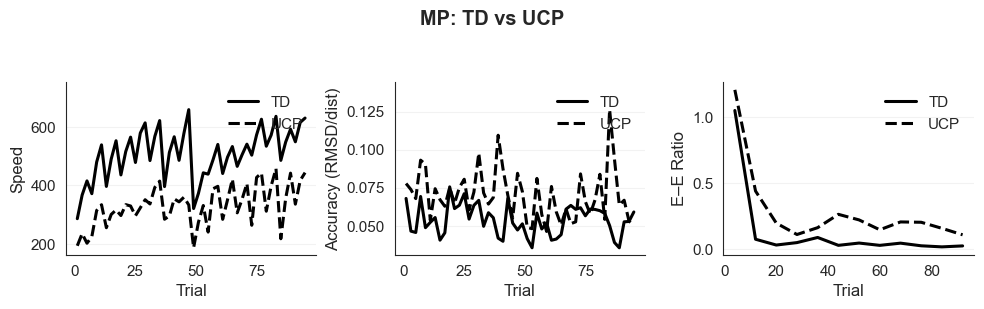

Saved: ../plots/comparison/RQ1/MSL_Unimanual_TERM_vs_PRETERM_macro2_micro12.png


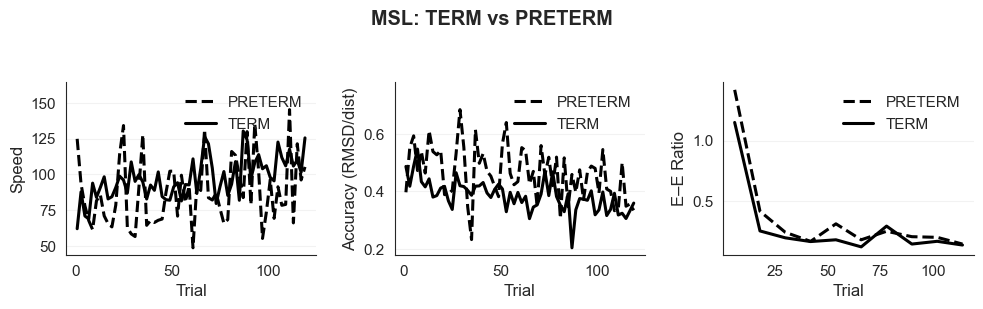

In [25]:
# Binned plots: mean lines only (Speed, Accuracy, E–E) per dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path
from typing import Optional

sns.set_style("white")

# Increase font size, reduce figure size (relative to previous)
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "legend.fontsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
})

# Parameters for experimenting with different window sizes
# (Macro: Speed/Accuracy; Micro: E–E)
msl_macro_bin_size = 2
msl_micro_bin_size = 12
ucpmp_macro_bin_size = 2
ucpmp_micro_bin_size = 8

MICRO_COL = "exploration_exploitation_ratio"
TIME_COL = "completion_time"
RMSD_COL = "rmsd"
DIST_COL = "actual_dist"


def _get_save_dir() -> Optional[Path]:
    if "save_path" not in globals() or save_path is None:
        print("save_path is not set; skipping saving plots.")
        return None
    out_dir = Path(save_path)
    out_dir.mkdir(parents=True, exist_ok=True)
    return out_dir


def _save_fig(fig: plt.Figure, filename: str) -> None:
    out_dir = _get_save_dir()
    if out_dir is None:
        return
    out_file = out_dir / filename
    fig.savefig(out_file, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_file}")


def _find_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None


def _rank_sessions(s: pd.Series) -> pd.Series:
    uniq = pd.Series(pd.unique(s))
    uniq_num = pd.to_numeric(uniq, errors="coerce")
    if uniq_num.notna().any():
        order = uniq.iloc[np.argsort(uniq_num.fillna(np.inf).values)]
    else:
        order = uniq.astype(str).sort_values()
    mapping = {val: i + 1 for i, val in enumerate(order)}
    return s.map(mapping)


def _ensure_seconds(df: pd.DataFrame, time_col: str = TIME_COL) -> pd.DataFrame:
    df = df.copy()
    if time_col not in df.columns:
        return df
    df[time_col] = pd.to_numeric(df[time_col], errors="coerce")
    med = float(df[time_col].median(skipna=True)) if df[time_col].notna().any() else np.nan
    # If median looks like milliseconds, convert to seconds
    if np.isfinite(med) and med > 50:
        df[time_col] = df[time_col] / 1000.0
    return df


def _ensure_actual_dist(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    if DIST_COL in df.columns:
        df[DIST_COL] = pd.to_numeric(df[DIST_COL], errors="coerce")
    return df


def _add_metrics(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in [MICRO_COL, TIME_COL, RMSD_COL, DIST_COL]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    if DIST_COL not in df.columns or TIME_COL not in df.columns:
        raise KeyError(f"Missing required columns for speed: {DIST_COL} and/or {TIME_COL}")
    if DIST_COL not in df.columns or RMSD_COL not in df.columns:
        raise KeyError(f"Missing required columns for rmsd_norm: {DIST_COL} and/or {RMSD_COL}")

    df["speed"] = np.where(
        df[DIST_COL].notna() & df[TIME_COL].notna() & (df[TIME_COL] > 0),
        df[DIST_COL] / df[TIME_COL],
        np.nan,
    )
    df["rmsd_norm"] = np.where(
        df[RMSD_COL].notna() & df[DIST_COL].notna() & (df[DIST_COL] > 0),
        df[RMSD_COL] / df[DIST_COL],
        np.nan,
    )
    return df


def _build_global_trial_index(
    df: pd.DataFrame,
    unit_col: str,
    session_col: str,
    trial_seq_col: str,
    trials_per_session: int,
    expected_total_trials: int,
) -> pd.Series:
    """Return global trial index per unit in [1..expected_total_trials].
    Uses trial_seq directly if it already looks global; otherwise builds it from session_rank + within-session order."""
    d = df[[unit_col, session_col, trial_seq_col]].copy()
    d[trial_seq_col] = pd.to_numeric(d[trial_seq_col], errors="coerce")
    d = d.dropna(subset=[trial_seq_col])
    d[trial_seq_col] = d[trial_seq_col].astype(int)

    d["session_rank"] = d.groupby(unit_col)[session_col].transform(_rank_sessions)

    meta = (
        d.groupby(unit_col)[trial_seq_col]
        .agg(max_trial="max", nunique="nunique")
        .reset_index()
    )
    meta["is_global"] = (meta["max_trial"] > trials_per_session) | (meta["nunique"] > trials_per_session)
    d = d.merge(meta[[unit_col, "is_global"]], on=unit_col, how="left")

    d = d.sort_values([unit_col, "session_rank", trial_seq_col])
    d["trial_in_session"] = d.groupby([unit_col, "session_rank"]).cumcount() + 1
    d["trial_global"] = np.where(
        d["is_global"],
        d[trial_seq_col],
        (d["session_rank"].astype(int) - 1) * trials_per_session + d["trial_in_session"].astype(int),
    )
    d["trial_global"] = pd.to_numeric(d["trial_global"], errors="coerce")

    out = df[[unit_col, session_col, trial_seq_col]].copy()
    out[trial_seq_col] = pd.to_numeric(out[trial_seq_col], errors="coerce")
    out = out.merge(
        d[[unit_col, session_col, trial_seq_col, "trial_global"]],
        on=[unit_col, session_col, trial_seq_col],
        how="left",
    )
    trial_global = pd.to_numeric(out["trial_global"], errors="coerce")
    trial_global = trial_global.where(trial_global.between(1, expected_total_trials))
    return trial_global


def _binned_mean(
    df_trials: pd.DataFrame,
    dataset: str,
    group_col: str,
    unit_col: str,
    session_col: str,
    trial_seq_col: str,
    trials_per_session: int,
    expected_total_trials: int,
    bin_size: int,
    metric: str,
) -> pd.DataFrame:
    d = df_trials.copy()
    d["group"] = d[group_col].astype(str).str.upper()
    d[unit_col] = d[unit_col].astype(str)

    d["trial_index"] = _build_global_trial_index(
        d,
        unit_col=unit_col,
        session_col=session_col,
        trial_seq_col=trial_seq_col,
        trials_per_session=trials_per_session,
        expected_total_trials=expected_total_trials,
    )
    d = d.dropna(subset=["trial_index"])
    d["trial_index"] = d["trial_index"].astype(int)

    if metric not in d.columns:
        raise KeyError(f"Missing metric column '{metric}' for {dataset}")

    d[metric] = pd.to_numeric(d[metric], errors="coerce")
    d = d.dropna(subset=[metric])

    bin_size = int(bin_size)
    d["bin"] = ((d["trial_index"].astype(int) - 1) // bin_size) + 1
    n_bins = int(np.ceil(expected_total_trials / bin_size))
    d = d[d["bin"].between(1, n_bins)].copy()
    d["x"] = (d["bin"] - 0.5) * bin_size

    # within-unit mean per bin to avoid over-weighting units with duplicates
    unit_bin = d.groupby([unit_col, "group", "bin", "x"], as_index=False)[metric].mean()

    # group mean across units per bin
    out = (
        unit_bin.groupby(["group", "bin", "x"], as_index=False)[metric]
        .mean()
        .rename(columns={metric: "mean"})
    )
    out["dataset"] = dataset
    return out


def _plot_metric(
    ax,
    df: pd.DataFrame,
    y_label: str,
    palette: dict,
    linestyles: dict,
    *,
    add_macro_headroom: bool = False,
    headroom_frac: float = 0.2,
):
    lw = 2.2
    for g, gdf in df.groupby("group"):
        gdf = gdf.sort_values("x")
        ax.plot(
            gdf["x"],
            gdf["mean"],
            label=str(g),
            color=palette.get(g, "black"),
            linestyle=linestyles.get(g, "-"),
            linewidth=lw,
        )

    if add_macro_headroom and df["mean"].notna().any():
        data_min = float(df["mean"].min())
        data_max = float(df["mean"].max())
        yrange = data_max - data_min
        pad = (yrange * float(headroom_frac)) if yrange > 0 else (abs(data_max) * float(headroom_frac) if data_max != 0 else 1.0)
        cur_ymin, cur_ymax = ax.get_ylim()
        new_ymax = max(cur_ymax, data_max + pad)
        ax.set_ylim(cur_ymin, new_ymax)

    ax.set_ylabel(y_label)
    ax.grid(axis="y", alpha=0.25)
    ax.legend(loc="upper right", frameon=False)
    sns.despine(ax=ax)


# -----------------
# UCPMP: TD vs UCP
# -----------------
if "ucpmp_df" not in globals():
    raise NameError("ucpmp_df not found. Run the load cells above.")

uc = ucpmp_df.copy()
uc = _ensure_seconds(uc)
uc = _ensure_actual_dist(uc)
uc = _add_metrics(uc)

uc_cohort_col = _find_col(uc, ["Cohort", "cohort", "GROUP", "Group", "group"])
if uc_cohort_col is None:
    raise KeyError("Could not find cohort column in ucpmp_df")
uc["cohort_norm"] = (
    uc[uc_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"UCPMP": "UCP", "UCP": "UCP", "TD": "TD", "TDC": "TD", "CONTROL": "TD", "TYPICAL": "TD"})
)
uc = uc[uc["cohort_norm"].isin(["TD", "UCP"])].copy()

if "participant_id" not in uc.columns:
    raise KeyError("ucpmp_df must have participant_id")
uc["unit_id"] = uc["participant_id"].astype(str)

uc_session_col = _find_col(uc, ["session_no", "session", "Session", "session_id"])
uc_trial_col = _find_col(uc, ["trial_seq", "trial", "trial_no", "Trial"])
if uc_session_col is None or uc_trial_col is None:
    raise KeyError("UCPMP requires session_no and trial_seq columns")

# Black/gray palette
uc_palette = {"TD": "black", "UCP": "black"}
# Use the same styles for macro and micro
uc_micro_styles = {"TD": "-", "UCP": "--"}
uc_macro_styles = uc_micro_styles

uc_speed = _binned_mean(
    uc,
    dataset="UCPMP",
    group_col="cohort_norm",
    unit_col="unit_id",
    session_col=uc_session_col,
    trial_seq_col=uc_trial_col,
    trials_per_session=48,
    expected_total_trials=96,
    bin_size=ucpmp_macro_bin_size,
    metric="speed",
)
uc_acc = _binned_mean(
    uc,
    dataset="UCPMP",
    group_col="cohort_norm",
    unit_col="unit_id",
    session_col=uc_session_col,
    trial_seq_col=uc_trial_col,
    trials_per_session=48,
    expected_total_trials=96,
    bin_size=ucpmp_macro_bin_size,
    metric="rmsd_norm",
)
uc_ee = _binned_mean(
    uc,
    dataset="UCPMP",
    group_col="cohort_norm",
    unit_col="unit_id",
    session_col=uc_session_col,
    trial_seq_col=uc_trial_col,
    trials_per_session=48,
    expected_total_trials=96,
    bin_size=ucpmp_micro_bin_size,
    metric=MICRO_COL,
)

fig, axes = plt.subplots(1, 3, figsize=(10.0, 2.9), sharex=False)
_plot_metric(axes[0], uc_speed, y_label="Speed", palette=uc_palette, linestyles=uc_macro_styles, add_macro_headroom=True)
_plot_metric(axes[1], uc_acc, y_label="Accuracy (RMSD/dist)", palette=uc_palette, linestyles=uc_macro_styles, add_macro_headroom=True)
_plot_metric(axes[2], uc_ee, y_label="E–E Ratio", palette=uc_palette, linestyles=uc_micro_styles, add_macro_headroom=False)

fig.suptitle(
    f"MP: TD vs UCP",
    y=1.06,
    fontweight="bold",
)
for ax in axes:
    ax.set_xlabel("Trial")
fig.tight_layout()
_save_fig(fig, f"UCPMP_TD_vs_UCP_macro{ucpmp_macro_bin_size}_micro{ucpmp_micro_bin_size}.png")
plt.show()


# -------------------------
# MSL: TERM vs PRETERM
# -------------------------
if "msl_df" not in globals():
    raise NameError("msl_df not found. Run the load cells above.")

ms = msl_df.copy()
ms = _ensure_seconds(ms)
ms = _ensure_actual_dist(ms)
ms = _add_metrics(ms)

ms_cohort_col = _find_col(ms, ["Cohort", "cohort", "GROUP", "Group", "group"])
if ms_cohort_col is None:
    raise KeyError("Could not find cohort column in msl_df")
ms["cohort_norm"] = (
    ms[ms_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"TERM": "TERM", "PRETERM": "PRETERM", "PRE-TERM": "PRETERM", "PT": "PRETERM"})
)
ms = ms[ms["cohort_norm"].isin(["TERM", "PRETERM"])].copy()

task_col = _find_col(ms, ["task_type", "task", "Task"])
if task_col is None:
    raise KeyError("msl_df must include task_type")
ms["task_type"] = pd.to_numeric(ms[task_col], errors="coerce")
ms_bi = ms[ms["task_type"] == 1].copy()

if "participant_id" not in ms_bi.columns:
    raise KeyError("msl_df must have participant_id")
ms_bi["unit_id"] = ms_bi["participant_id"].astype(str)

ms_session_col = _find_col(ms_bi, ["session_no", "session", "Session", "session_id"])
ms_trial_col = _find_col(ms_bi, ["trial_seq", "trial", "trial_no", "Trial"])
if ms_session_col is None or ms_trial_col is None:
    raise KeyError("MSL requires session_no and trial_seq columns")

ms_palette = {"TERM": "black", "PRETERM": "black"}
# Use the same styles for macro and micro
ms_micro_styles = {"TERM": "-", "PRETERM": "--"}
ms_macro_styles = ms_micro_styles

ms_speed = _binned_mean(
    ms_bi,
    dataset="MSL",
    group_col="cohort_norm",
    unit_col="unit_id",
    session_col=ms_session_col,
    trial_seq_col=ms_trial_col,
    trials_per_session=24,
    expected_total_trials=120,
    bin_size=msl_macro_bin_size,
    metric="speed",
)
ms_acc = _binned_mean(
    ms_bi,
    dataset="MSL",
    group_col="cohort_norm",
    unit_col="unit_id",
    session_col=ms_session_col,
    trial_seq_col=ms_trial_col,
    trials_per_session=24,
    expected_total_trials=120,
    bin_size=msl_macro_bin_size,
    metric="rmsd_norm",
)
ms_ee = _binned_mean(
    ms_bi,
    dataset="MSL",
    group_col="cohort_norm",
    unit_col="unit_id",
    session_col=ms_session_col,
    trial_seq_col=ms_trial_col,
    trials_per_session=24,
    expected_total_trials=120,
    bin_size=msl_micro_bin_size,
    metric=MICRO_COL,
)

fig, axes = plt.subplots(1, 3, figsize=(10.0, 2.9), sharex=False)
_plot_metric(axes[0], ms_speed, y_label="Speed", palette=ms_palette, linestyles=ms_macro_styles, add_macro_headroom=True)
_plot_metric(axes[1], ms_acc, y_label="Accuracy (RMSD/dist)", palette=ms_palette, linestyles=ms_macro_styles, add_macro_headroom=True)
_plot_metric(axes[2], ms_ee, y_label="E–E Ratio", palette=ms_palette, linestyles=ms_micro_styles, add_macro_headroom=False)

fig.suptitle(
    f"MSL: TERM vs PRETERM",
    y=1.06,
    fontweight="bold",
)
for ax in axes:
    ax.set_xlabel("Trial")
fig.tight_layout()
_save_fig(fig, f"MSL_Unimanual_TERM_vs_PRETERM_macro{msl_macro_bin_size}_micro{msl_micro_bin_size}.png")
plt.show()


# -------------------------
# MSL (Unimanual): TERM vs PRETERM
# -------------------------
# ms_uni = ms[ms["task_type"] == 0].copy()  # Unimanual only
# if ms_uni.empty:
#     print("No MSL unimanual trials found (task_type == 0). Skipping unimanual plot.")
# else:
#     if "participant_id" not in ms_uni.columns:
#         raise KeyError("msl_df must have participant_id")
#     ms_uni["unit_id"] = ms_uni["participant_id"].astype(str)
#
#     ms_uni_session_col = _find_col(ms_uni, ["session_no", "session", "Session", "session_id"])
#     ms_uni_trial_col = _find_col(ms_uni, ["trial_seq", "trial", "trial_no", "Trial"])
#     if ms_uni_session_col is None or ms_uni_trial_col is None:
#         raise KeyError("MSL requires session_no and trial_seq columns")
#
#     ms_uni_palette = {"TERM": "black", "PRETERM": "0.55"}
#     ms_uni_micro_styles = {"TERM": "-", "PRETERM": "-"}
#     ms_uni_macro_styles = ms_uni_micro_styles
#
#     ms_uni_speed = _binned_mean(
#         ms_uni,
#         dataset="MSL (Unimanual)",
#         group_col="cohort_norm",
#         unit_col="unit_id",
#         session_col=ms_uni_session_col,
#         trial_seq_col=ms_uni_trial_col,
#         trials_per_session=24,
#         expected_total_trials=120,
#         bin_size=msl_macro_bin_size,
#         metric="speed",
#     )
#     ms_uni_acc = _binned_mean(
#         ms_uni,
#         dataset="MSL (Unimanual)",
#         group_col="cohort_norm",
#         unit_col="unit_id",
#         session_col=ms_uni_session_col,
#         trial_seq_col=ms_uni_trial_col,
#         trials_per_session=24,
#         expected_total_trials=120,
#         bin_size=msl_macro_bin_size,
#         metric="rmsd_norm",
#     )
#     ms_uni_ee = _binned_mean(
#         ms_uni,
#         dataset="MSL (Unimanual)",
#         group_col="cohort_norm",
#         unit_col="unit_id",
#         session_col=ms_uni_session_col,
#         trial_seq_col=ms_uni_trial_col,
#         trials_per_session=24,
#         expected_total_trials=120,
#         bin_size=msl_micro_bin_size,
#         metric=MICRO_COL,
#     )
#
#     fig, axes = plt.subplots(1, 3, figsize=(13.2, 3.7), sharex=False)
#     _plot_metric(axes[0], ms_uni_speed, y_label="Speed", palette=ms_uni_palette, linestyles=ms_uni_macro_styles, add_macro_headroom=True)
#     _plot_metric(axes[1], ms_uni_acc, y_label="Accuracy (RMSD/dist)", palette=ms_uni_palette, linestyles=ms_uni_macro_styles, add_macro_headroom=True)
#     _plot_metric(axes[2], ms_uni_ee, y_label="E–E ratio", palette=ms_uni_palette, linestyles=ms_uni_micro_styles, add_macro_headroom=False)
#
#     fig.suptitle(
#         f"MSL (Unimanual): TERM vs PRETERM",
#         y=1.06,
#         fontweight="bold",
#     )
#     for ax in axes:
#         ax.set_xlabel("Trial progression")
#     fig.tight_layout()
#     _save_fig(fig, f"MSL_Unimanual_TERM_vs_PRETERM_macro{msl_macro_bin_size}_micro{msl_micro_bin_size}.png")
#     plt.show()

In [ ]:
### Additional exploratory analyses: correlations between metrics, trial-wise changes in micro metric, etc.

In [22]:
# Additional RQ1 statistics: metric correlations + trial-wise trends
import numpy as np
import pandas as pd
import scipy.stats as stats

MICRO_COL = "exploration_exploitation_ratio"

def _pearson_spearman(x: pd.Series, y: pd.Series):
    x = pd.to_numeric(pd.Series(x), errors="coerce").astype(float)
    y = pd.to_numeric(pd.Series(y), errors="coerce").astype(float)
    mask = x.notna() & y.notna()
    x = x[mask]
    y = y[mask]
    n = int(x.shape[0])
    if n < 3:
        return {"n": n, "pearson_r": np.nan, "pearson_p": np.nan, "spearman_r": np.nan, "spearman_p": np.nan}
    pr = stats.pearsonr(x, y)
    sr = stats.spearmanr(x, y)
    return {
        "n": n,
        "pearson_r": float(pr.statistic),
        "pearson_p": float(pr.pvalue),
        "spearman_r": float(sr.statistic),
        "spearman_p": float(sr.pvalue),
    }

def _corr_table(df: pd.DataFrame, group_col: str, groups: list, metric_pairs: list, dataset_label: str):
    rows = []
    for g in groups:
        gdf = df[df[group_col] == g]
        for m1, m2 in metric_pairs:
            stats_out = _pearson_spearman(gdf[m1], gdf[m2])
            rows.append({
                "dataset": dataset_label,
                "group": g,
                "metric_x": m1,
                "metric_y": m2,
                **stats_out,
            })
    return pd.DataFrame(rows)

# ---------------------------
# Build trial-level datasets
# ---------------------------
if "ucpmp_df" not in globals() or "msl_df" not in globals():
    raise NameError("ucpmp_df and msl_df must be loaded before running this cell.")

# Reuse helpers if defined earlier
if "_ensure_seconds" not in globals() or "_ensure_actual_dist" not in globals() or "_add_metrics" not in globals() or "_find_col" not in globals():
    raise NameError("Expected helper functions (_ensure_seconds/_ensure_actual_dist/_add_metrics/_find_col) are missing.")

uc = ucpmp_df.copy()
uc = _ensure_seconds(uc)
uc = _ensure_actual_dist(uc)
uc = _add_metrics(uc)
uc_cohort_col = _find_col(uc, ["Cohort", "cohort", "GROUP", "Group", "group"])
if uc_cohort_col is None:
    raise KeyError("Could not find cohort column in ucpmp_df")
uc["cohort_norm"] = (
    uc[uc_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"UCPMP": "UCP", "UCP": "UCP", "TD": "TD", "TDC": "TD", "CONTROL": "TD", "TYPICAL": "TD"})
)
uc = uc[uc["cohort_norm"].isin(["TD", "UCP"])].copy()

ms = msl_df.copy()
ms = _ensure_seconds(ms)
ms = _ensure_actual_dist(ms)
ms = _add_metrics(ms)
ms_cohort_col = _find_col(ms, ["Cohort", "cohort", "GROUP", "Group", "group"])
if ms_cohort_col is None:
    raise KeyError("Could not find cohort column in msl_df")
ms["cohort_norm"] = (
    ms[ms_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({"TERM": "TERM", "PRETERM": "PRETERM", "PRE-TERM": "PRETERM", "PT": "PRETERM"})
)
task_col = _find_col(ms, ["task_type", "task", "Task"])
if task_col is None:
    raise KeyError("msl_df must include task_type")
ms["task_type"] = pd.to_numeric(ms[task_col], errors="coerce")
ms = ms[(ms["task_type"] == 0) & (ms["cohort_norm"].isin(["TERM", "PRETERM"]))].copy()

metric_pairs = [("speed", "rmsd_norm"), ("speed", MICRO_COL), ("rmsd_norm", MICRO_COL)]
uc_corr = _corr_table(uc, "cohort_norm", ["TD", "UCP"], metric_pairs, "UCPMP")
ms_corr = _corr_table(ms, "cohort_norm", ["TERM", "PRETERM"], metric_pairs, "MSL (Unimanual)")
corr_df = pd.concat([uc_corr, ms_corr], ignore_index=True)
display(corr_df)

# --------------------------------------
# Trial-wise trend stats (binned lines)
# --------------------------------------
def _build_trial_index(df: pd.DataFrame, session_col: str, trial_col: str, trials_per_session: int):
    sess = pd.to_numeric(df[session_col], errors="coerce")
    trial = pd.to_numeric(df[trial_col], errors="coerce")
    return (sess - 1) * int(trials_per_session) + trial

def _binned_progression_units_local(
    df: pd.DataFrame,
    group_col: str,
    unit_cols: list,
    metric_cols: list,
    session_col: str,
    trial_col: str,
    trials_per_session: int,
    expected_total_trials: int,
    bin_size: int,
    dataset_label: str,
 ):
    d = df.copy()
    d["trial_index"] = _build_trial_index(d, session_col, trial_col, trials_per_session)
    d = d.dropna(subset=["trial_index"]).copy()
    d["trial_index"] = d["trial_index"].astype(int)
    d["bin"] = ((d["trial_index"] - 1) // int(bin_size)) + 1
    n_bins = int(np.ceil(expected_total_trials / int(bin_size)))
    d = d[d["bin"].between(1, n_bins)].copy()
    d["x"] = (d["bin"] - 0.5) * int(bin_size)
    cols = unit_cols + [group_col, "bin", "x"] + metric_cols
    d = d[cols].copy()
    out = d.groupby(unit_cols + [group_col, "bin", "x"], as_index=False)[metric_cols].mean()
    out = out.rename(columns={group_col: "group"})
    out["dataset"] = dataset_label
    return out

uc_session_col = _find_col(uc, ["session_no", "session", "Session", "session_id"])
uc_trial_col = _find_col(uc, ["trial_no", "trial", "Trial", "trial_id", "trial_seq", "trial_index"])
if uc_session_col is None or uc_trial_col is None:
    raise KeyError("Could not find session/trial columns in ucpmp_df for binning")

ms_session_col = _find_col(ms, ["session_no", "session", "Session", "session_id"])
ms_trial_col = _find_col(ms, ["trial_no", "trial", "Trial", "trial_id", "trial_seq", "trial_index"])
if ms_session_col is None or ms_trial_col is None:
    raise KeyError("Could not find session/trial columns in msl_df for binning")

# Requested bin sizes
ucpmp_macro_bin_size = 2
ucpmp_micro_bin_size = 8
msl_macro_bin_size = 3
msl_micro_bin_size = 12

uc_prog_macro = _binned_progression_units_local(
    uc,
    "cohort_norm",
    ["participant_id"],
    ["speed", "rmsd_norm"],
    uc_session_col,
    uc_trial_col,
    trials_per_session=48,
    expected_total_trials=96,
    bin_size=ucpmp_macro_bin_size,
    dataset_label="UCPMP",
 )
uc_prog_micro = _binned_progression_units_local(
    uc,
    "cohort_norm",
    ["participant_id"],
    [MICRO_COL],
    uc_session_col,
    uc_trial_col,
    trials_per_session=48,
    expected_total_trials=96,
    bin_size=ucpmp_micro_bin_size,
    dataset_label="UCPMP",
 )
ms_prog_macro = _binned_progression_units_local(
    ms,
    "cohort_norm",
    ["participant_id"],
    ["speed", "rmsd_norm"],
    ms_session_col,
    ms_trial_col,
    trials_per_session=24,
    expected_total_trials=120,
    bin_size=msl_macro_bin_size,
    dataset_label="MSL (Unimanual)",
 )
ms_prog_micro = _binned_progression_units_local(
    ms,
    "cohort_norm",
    ["participant_id"],
    [MICRO_COL],
    ms_session_col,
    ms_trial_col,
    trials_per_session=24,
    expected_total_trials=120,
    bin_size=msl_micro_bin_size,
    dataset_label="MSL (Unimanual)",
 )

macro_df = pd.concat([ms_prog_macro, uc_prog_macro], ignore_index=True)
micro_df = pd.concat([ms_prog_micro, uc_prog_micro], ignore_index=True)

def _trend_stats(df: pd.DataFrame, metric: str):
    rows = []
    for (dataset, group), gdf in df.groupby(["dataset", "group"]):
        gdf = gdf.dropna(subset=[metric, "x"]).copy()
        if gdf.empty:
            continue
        mean_by_x = gdf.groupby("x", as_index=False)[metric].mean()
        if mean_by_x.shape[0] < 3:
            continue
        lr = stats.linregress(mean_by_x["x"], mean_by_x[metric])
        rows.append({
            "dataset": dataset,
            "group": group,
            "metric": metric,
            "slope": float(lr.slope),
            "p_value": float(lr.pvalue),
            "r_value": float(lr.rvalue),
            "n_bins": int(mean_by_x.shape[0]),
        })
    return pd.DataFrame(rows)

trend_macro = pd.concat([
    _trend_stats(macro_df, "speed"),
    _trend_stats(macro_df, "rmsd_norm"),
], ignore_index=True)
trend_micro = _trend_stats(micro_df, MICRO_COL)
trend_df = pd.concat([trend_macro, trend_micro], ignore_index=True)
display(trend_df)


,dataset,group,metric_x,metric_y,n,pearson_r,pearson_p,spearman_r,spearman_p
0,UCPMP,TD,speed,rmsd_norm,3840,-0.328876,1.559505e-97,-0.344909,1.036798e-107
1,UCPMP,TD,speed,exploration_exploitation_ratio,3840,-0.203207,4.514028e-37,-0.612439,0.000000e+00
2,UCPMP,TD,rmsd_norm,exploration_exploitation_ratio,3840,0.090625,1.848653e-08,0.423774,3.263087e-167
3,UCPMP,UCP,speed,rmsd_norm,960,-0.360659,7.292343e-31,-0.402259,1.215648e-38
4,UCPMP,UCP,speed,exploration_exploitation_ratio,960,-0.289292,5.799030e-20,-0.771409,2.867225e-190
5,UCPMP,UCP,rmsd_norm,exploration_exploitation_ratio,960,0.187939,4.414824e-09,0.462651,4.359460e-52
6,MSL (Unimanual),TERM,speed,rmsd_norm,6000,-0.570333,0.000000e+00,-0.709634,0.000000e+00
7,MSL (Unimanual),TERM,speed,exploration_exploitation_ratio,6000,-0.065035,4.609604e-07,-0.344326,1.282443e-166
8,MSL (Unimanual),TERM,rmsd_norm,exploration_exploitation_ratio,6000,0.064641,5.407937e-07,0.328912,2.357044e-151
9,MSL (Unimanual),PRETERM,speed,rmsd_norm,2160,-0.379621,5.397858e-75,-0.591403,5.896710e-204


,dataset,group,metric,slope,p_value,r_value,n_bins
0,MSL (Unimanual),PRETERM,speed,0.605157,6.360686e-11,0.824209,40
1,MSL (Unimanual),TERM,speed,0.836205,2.526847e-24,0.967621,40
2,UCPMP,TD,speed,0.620036,5.362783e-01,0.258618,8
3,UCPMP,UCP,speed,0.992994,1.203510e-01,0.594190,8
4,MSL (Unimanual),PRETERM,rmsd_norm,-0.001727,6.778555e-12,-0.845348,40
5,MSL (Unimanual),TERM,rmsd_norm,-0.002190,2.675596e-23,-0.963266,40
6,UCPMP,TD,rmsd_norm,-0.000082,2.977658e-01,-0.421925,8
7,UCPMP,UCP,rmsd_norm,-0.000179,1.243410e-01,-0.589152,8
8,MSL (Unimanual),PRETERM,exploration_exploitation_ratio,-0.004337,4.279926e-03,-0.812538,10
9,MSL (Unimanual),TERM,exploration_exploitation_ratio,-0.004736,2.345878e-02,-0.702604,10


### Statistical Analysis

,group,mean,ci_low,ci_high,n_units
0,Monkey,0.055629,0.042469,0.068788,384
1,UCP,0.283508,0.144173,0.422843,10
2,TD,0.123079,0.099601,0.146557,40
3,Term,0.254543,0.228136,0.280949,50
4,Preterm,0.291969,0.260057,0.323880,18


Saved figure to: ../plots/comparison/RQ1/All_Dataset_E-E_Ratio_BoxPlot.png


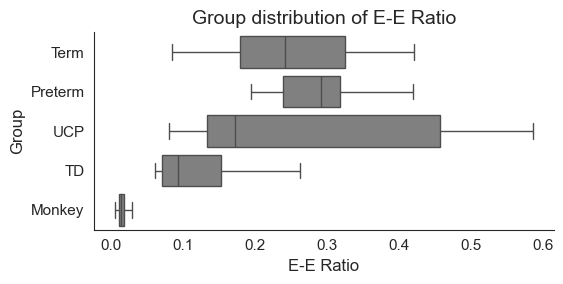

In [23]:
# Group-wise E-E ratio summary (mean +/- 95% CI) + box plot
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

MICRO_COL = "exploration_exploitation_ratio"

def _find_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _ci95_t(x):
    vals = pd.to_numeric(pd.Series(x), errors="coerce").dropna().astype(float)
    n = int(vals.shape[0])
    if n == 0:
        return np.nan, np.nan, np.nan, 0
    mean = float(vals.mean())
    if n < 2:
        return mean, np.nan, np.nan, n
    sem = stats.sem(vals, nan_policy="omit")
    h = stats.t.ppf(0.975, df=n - 1) * sem
    return mean, mean - float(h), mean + float(h), n

summary_rows = []
box_parts = []

# ----------------------------------------------
# Monkey (session-level means: exp x session_id)
# ----------------------------------------------
if "monkeypd_df" in globals():
    monkey_df = monkeypd_df.copy()
elif "monkeypr_df" in globals():
    monkey_df = monkeypr_df.copy()
else:
    raise NameError("Neither monkeypd_df nor monkeypr_df is available.")

if MICRO_COL not in monkey_df.columns:
    raise KeyError(f"{MICRO_COL} not found in monkey dataframe")

monkey_df[MICRO_COL] = pd.to_numeric(monkey_df[MICRO_COL], errors="coerce")
monkey_exp_col = _find_col(monkey_df, ["exp_type", "experiment", "exp", "ExpType"])
monkey_sess_col = _find_col(monkey_df, ["session_no", "session", "Session", "session_id"])
if monkey_exp_col is not None and monkey_sess_col is not None:
    monkey_units = (
        monkey_df.groupby([monkey_exp_col, monkey_sess_col], as_index=False)[MICRO_COL]
        .mean()
        .dropna(subset=[MICRO_COL])
    )
    monkey_vals = monkey_units[MICRO_COL]
else:
    # Fallback to trial-level if session identifiers are unavailable
    monkey_vals = monkey_df[MICRO_COL].dropna()

m_mean, m_lo, m_hi, m_n = _ci95_t(monkey_vals)
summary_rows.append({
    "group": "Monkey",
    "mean": m_mean,
    "ci_low": m_lo,
    "ci_high": m_hi,
    "n_units": m_n,
})
box_parts.append(pd.DataFrame({"group": "Monkey", MICRO_COL: monkey_vals.values}))

# --------------------------------
# UCPMP (participant-level means)
# --------------------------------
if "ucpmp_df" not in globals():
    raise NameError("ucpmp_df is not available.")

uc = ucpmp_df.copy()
if MICRO_COL not in uc.columns:
    raise KeyError(f"{MICRO_COL} not found in ucpmp_df")
if "participant_id" not in uc.columns:
    raise KeyError("participant_id not found in ucpmp_df")

uc_cohort_col = _find_col(uc, ["Cohort", "cohort", "GROUP", "Group", "group"])
if uc_cohort_col is None:
    raise KeyError("Could not find cohort column in ucpmp_df")

uc["cohort_norm"] = (
    uc[uc_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        "UCP": "UCP",
        "UCPMP": "UCP",
        "TD": "TD",
        "TDC": "TD",
        "CONTROL": "TD",
        "TYPICAL": "TD",
    })
)
uc = uc[uc["cohort_norm"].isin(["UCP", "TD"])].copy()
uc[MICRO_COL] = pd.to_numeric(uc[MICRO_COL], errors="coerce")

uc_units = (
    uc.groupby(["participant_id", "cohort_norm"], as_index=False)[MICRO_COL]
    .mean()
    .dropna(subset=[MICRO_COL])
)

for g in ["UCP", "TD"]:
    vals = uc_units.loc[uc_units["cohort_norm"] == g, MICRO_COL]
    mean, lo, hi, n = _ci95_t(vals)
    summary_rows.append({
        "group": g,
        "mean": mean,
        "ci_low": lo,
        "ci_high": hi,
        "n_units": n,
    })
    if n > 0:
        box_parts.append(pd.DataFrame({"group": g, MICRO_COL: vals.values}))

# -----------------------------------------------------
# MSL (participant-level means by cohort; Unimanual only)
# -----------------------------------------------------
if "msl_df" not in globals():
    raise NameError("msl_df is not available.")

ms = msl_df.copy()
if MICRO_COL not in ms.columns:
    raise KeyError(f"{MICRO_COL} not found in msl_df")
if "participant_id" not in ms.columns:
    raise KeyError("participant_id not found in msl_df")

ms_cohort_col = _find_col(ms, ["Cohort", "cohort", "GROUP", "Group", "group"])
if ms_cohort_col is None:
    raise KeyError("Could not find cohort column in msl_df")

task_col = _find_col(ms, ["task_type", "task", "Task"])
if task_col is None:
    raise KeyError("Could not find task_type column in msl_df")

ms["cohort_norm"] = (
    ms[ms_cohort_col]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        "TERM": "Term",
        "PRETERM": "Preterm",
        "PRE-TERM": "Preterm",
        "PT": "Preterm",
    })
)
ms["task_type_num"] = pd.to_numeric(ms[task_col], errors="coerce")
ms[MICRO_COL] = pd.to_numeric(ms[MICRO_COL], errors="coerce")

ms = ms[
    ms["cohort_norm"].isin(["Term", "Preterm"])
    & (ms["task_type_num"] == 0)
].copy()

ms_units = (
    ms.groupby(["participant_id", "cohort_norm"], as_index=False)[MICRO_COL]
    .mean()
    .dropna(subset=[MICRO_COL])
)

for label in ["Term", "Preterm"]:
    vals = ms_units.loc[ms_units["cohort_norm"] == label, MICRO_COL]
    mean, lo, hi, n = _ci95_t(vals)
    summary_rows.append({
        "group": label,
        "mean": mean,
        "ci_low": lo,
        "ci_high": hi,
        "n_units": n,
    })
    if n > 0:
        box_parts.append(pd.DataFrame({"group": label, MICRO_COL: vals.values}))

summary_df = pd.DataFrame(summary_rows)
group_order = [
    "Monkey",
    "UCP",
    "TD",
    "Term",
    "Preterm",
]
summary_df["group"] = pd.Categorical(summary_df["group"], categories=group_order, ordered=True)
summary_df = summary_df.sort_values("group").reset_index(drop=True)

# Match your requested output layout
display(summary_df[["group", "mean", "ci_low", "ci_high", "n_units"]])

# Horizontal box plot across all groups (box only)
box_df = pd.concat(box_parts, ignore_index=True)
box_order = [
    "Term",
    "Preterm",
    "UCP",
    "TD",
    "Monkey"
]
box_df["group"] = pd.Categorical(box_df["group"], categories=box_order, ordered=True)
box_df = box_df.dropna(subset=[MICRO_COL]).sort_values("group")

plt.figure(figsize=(5.8, 3.0))
sns.boxplot(
    data=box_df,
    x=MICRO_COL,
    y="group",
    color="0.5",
    showfliers=False,
    linewidth=1.0,
)
plt.title("Group distribution of E-E Ratio")
plt.xlabel("E-E Ratio")
plt.ylabel("Group")
sns.despine()
plt.tight_layout()
# Save to save_path directory
if "save_path" in globals() and isinstance(save_path, str) and len(save_path.strip()) > 0:
    out_dir = Path(save_path)
else:
    out_dir = Path(".")
out_dir.mkdir(parents=True, exist_ok=True)

out_png = out_dir / f"All_Dataset_E-E_Ratio_BoxPlot.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
print(f"Saved figure to: {out_png}")
plt.show()


### RQ4: Trial Progression Slope Distributions (E-E ratio)

In [28]:
# Density of trial-progression slopes (E-E ratio) across cohorts
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

MICRO_COL = "exploration_exploitation_ratio"

def _find_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _bin_trials_by_unit(
    df: pd.DataFrame,
    unit_cols: list,
    trial_col: str,
    n_bins: int = 10,
    ratio_col: str = MICRO_COL,
 ) -> pd.DataFrame:
    """Bin trials within each unit and compute mean E-E per bin with trial_percentage (0-100)."""
    rows = []
    d = df.copy()
    d[ratio_col] = pd.to_numeric(d[ratio_col], errors="coerce")
    d[trial_col] = pd.to_numeric(d[trial_col], errors="coerce")
    d = d.dropna(subset=[ratio_col, trial_col])
    for unit_vals, g in d.groupby(unit_cols):
        if len(g) < 5:
            continue
        g = g.sort_values(trial_col)
        max_trials = g[trial_col].max()
        if max_trials <= 1:
            continue
        bin_size = max(1, max_trials / n_bins)
        g = g.copy()
        g["trial_bin"] = ((g[trial_col] - 1) // bin_size).astype(int)
        g["trial_bin"] = np.minimum(g["trial_bin"], n_bins - 1)
        binned = g.groupby("trial_bin", as_index=False)[ratio_col].mean()
        binned["trial_percentage"] = (binned["trial_bin"] / (n_bins - 1)) * 100.0
        if not isinstance(unit_vals, tuple):
            unit_vals = (unit_vals,)
        unit_id = "_".join([str(v) for v in unit_vals])
        binned["unit_id"] = unit_id
        rows.append(binned[["unit_id", "trial_percentage", ratio_col]])
    if not rows:
        return pd.DataFrame(columns=["unit_id", "trial_percentage", ratio_col])
    return pd.concat(rows, ignore_index=True)

def _ols_slope(df: pd.DataFrame, ratio_col: str = MICRO_COL) -> float:
    if df.empty:
        return np.nan
    model = smf.ols(f"{ratio_col} ~ trial_percentage", data=df).fit()
    return float(model.params.get("trial_percentage", np.nan))

def _bootstrap_slopes(
    binned_df: pd.DataFrame,
    n_boot: int = 2000,
    seed: int = 42,
    ratio_col: str = MICRO_COL,
 ) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    units = binned_df["unit_id"].dropna().unique()
    if units.size == 0:
        return pd.DataFrame(columns=["slope"])
    unit_groups = {uid: binned_df[binned_df["unit_id"] == uid] for uid in units}
    slopes = []
    for _ in range(n_boot):
        sampled = rng.choice(units, size=len(units), replace=True)
        sample_df = pd.concat([unit_groups[uid] for uid in sampled], ignore_index=True)
        slopes.append(_ols_slope(sample_df, ratio_col=ratio_col))
    return pd.DataFrame({"slope": slopes})

def _normalize_cohort(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    s_upper = s.str.upper()
    mapped = s_upper.replace({
        "UCP": "UCP",
        "TD": "TD",
        "TERM": "Term",
        "PRETERM": "Preterm",
        "PRE-TERM": "Preterm",
        "MONKEY": "Monkey",
    })
    # Keep original title case for Term/Preterm, otherwise use upper for UCP/TD
    mapped = mapped.replace({"UCP": "UCP", "TD": "TD"})
    return mapped

# ---- Build binned data for each cohort ----
binned_by_cohort = {}

# MonkeyPR: cohort = Monkey, unit = exp_type + session_no, use trial_no
if "monkeypr_df" not in globals() and "monkeypd_df" not in globals():
    raise NameError("monkeypr_df or monkeypd_df not found. Run the load cells above.")
monkey_src = monkeypd_df if "monkeypd_df" in globals() else monkeypr_df
monkey_exp_col = _find_col(monkey_src, ["exp_type", "experiment", "exp", "ExpType"])
monkey_sess_col = _find_col(monkey_src, ["session_no", "session", "Session", "session_id"])
monkey_trial_col = _find_col(monkey_src, ["trial_no", "trial", "Trial"])
if monkey_exp_col is None or monkey_sess_col is None or monkey_trial_col is None:
    raise KeyError("MonkeyPR requires exp_type, session_no, trial_no columns")
monkey_bins = _bin_trials_by_unit(
    monkey_src,
    unit_cols=[monkey_exp_col, monkey_sess_col],
    trial_col=monkey_trial_col,
    n_bins=10,
 )
binned_by_cohort["Monkey"] = monkey_bins

# UCPMP: cohorts UCP/TD, unit = participant_id + session_no, use trial_seq
if "ucpmp_df" not in globals():
    raise NameError("ucpmp_df not found. Run the load cells above.")
uc = ucpmp_df.copy()
uc_cohort_col = _find_col(uc, ["Cohort", "cohort", "GROUP", "Group", "group"])
if uc_cohort_col is None:
    raise KeyError("UCPMP requires Cohort column")
uc["Cohort_norm"] = _normalize_cohort(uc[uc_cohort_col])
uc = uc[uc["Cohort_norm"].isin(["UCP", "TD"])].copy()
uc_session_col = _find_col(uc, ["session_no", "session", "Session", "session_id"])
uc_trial_col = _find_col(uc, ["trial_seq", "trial", "trial_no", "Trial"])
if uc_session_col is None or uc_trial_col is None:
    raise KeyError("UCPMP requires session_no and trial_seq columns")
if "participant_id" not in uc.columns:
    raise KeyError("UCPMP requires participant_id column")
for cohort in ["UCP", "TD"]:
    uc_sub = uc[uc["Cohort_norm"] == cohort].copy()
    uc_bins = _bin_trials_by_unit(
        uc_sub,
        unit_cols=["participant_id", uc_session_col],
        trial_col=uc_trial_col,
        n_bins=10,
    )
    binned_by_cohort[cohort] = uc_bins

# MSL: cohorts Term/Preterm, unit = participant_id + session_no, use trial_seq
if "msl_df" not in globals():
    raise NameError("msl_df not found. Run the load cells above.")
ms = msl_df.copy()
ms_task_col = _find_col(ms, ["task_type", "task", "Task"])
if ms_task_col is None:
    raise KeyError("MSL requires task_type column")
ms["task_type"] = pd.to_numeric(ms[ms_task_col], errors="coerce")
ms = ms[ms["task_type"] == 0].copy()  # Unimanual only
ms_cohort_col = _find_col(ms, ["Cohort", "cohort", "GROUP", "Group", "group"])
if ms_cohort_col is None:
    raise KeyError("MSL requires Cohort column")
ms["Cohort_norm"] = _normalize_cohort(ms[ms_cohort_col])
ms = ms[ms["Cohort_norm"].isin(["Term", "Preterm"])].copy()
ms_session_col = _find_col(ms, ["session_no", "session", "Session", "session_id"])
ms_trial_col = _find_col(ms, ["trial_seq", "trial", "trial_no", "Trial"])
if ms_session_col is None or ms_trial_col is None:
    raise KeyError("MSL requires session_no and trial_seq columns")
if "participant_id" not in ms.columns:
    raise KeyError("MSL requires participant_id column")
for cohort in ["Term", "Preterm"]:
    ms_sub = ms[ms["Cohort_norm"] == cohort].copy()
    ms_bins = _bin_trials_by_unit(
        ms_sub,
        unit_cols=["participant_id", ms_session_col],
        trial_col=ms_trial_col,
        n_bins=10,
    )
    binned_by_cohort[cohort] = ms_bins

# ---- Compute slopes + bootstrap distributions ----
slope_summary_rows = []
boot_rows = []
for cohort, binned_df in binned_by_cohort.items():
    slope = _ols_slope(binned_df)
    boot_df = _bootstrap_slopes(binned_df, n_boot=2000, seed=42)
    boot_df["cohort"] = cohort
    boot_rows.append(boot_df)
    if not boot_df.empty:
        ci_low, ci_high = np.percentile(boot_df["slope"], [2.5, 97.5])
        mean_slope = float(boot_df["slope"].mean())
    else:
        ci_low, ci_high, mean_slope = np.nan, np.nan, np.nan
    slope_summary_rows.append({
        "cohort": cohort,
        "slope": slope,
        "boot_mean": mean_slope,
        "boot_ci_low": ci_low,
        "boot_ci_high": ci_high,
        "n_units": int(binned_df["unit_id"].nunique()),
    })

boot_all = pd.concat(boot_rows, ignore_index=True) if boot_rows else pd.DataFrame(columns=["cohort", "slope"])
summary_df = pd.DataFrame(slope_summary_rows)
display(summary_df)

,cohort,slope,boot_mean,boot_ci_low,boot_ci_high,n_units
0,Monkey,-0.000090,-0.000092,-0.000308,0.000097,384
1,UCP,-0.007684,-0.007680,-0.011505,-0.004624,20
2,TD,-0.007050,-0.007054,-0.008615,-0.005655,80
3,Term,-0.010649,-0.010650,-0.011878,-0.009383,250
4,Preterm,-0.007893,-0.007885,-0.009625,-0.006326,90


Saved figure to: ../plots/comparison/RQ1/E-E_Slope_distribution_CohortWise.png


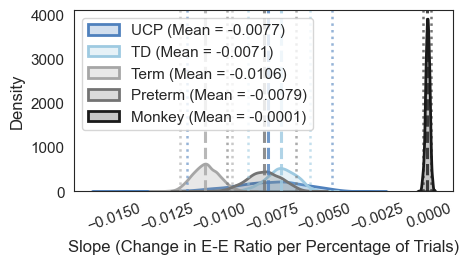

In [29]:
# ---- Density plot (use bootstrap samples for density) ----
plt.figure(figsize=(4.8, 2.8))
plot_order = ["UCP", "TD", "Term", "Preterm", "Monkey"]
available = [c for c in plot_order if c in boot_all["cohort"].unique()]

# Use light blue for TD, darker blue for UCP, gray for Term/Preterm, black for Monkey
group_family = {
    "UCP": "ucpmp",
    "TD": "ucpmp",
    "Term": "msl",
    "Preterm": "msl",
    "Monkey": "monkey",
}
family_colors = {
    "ucpmp": "#9ecae1",  # light blue
    "msl": "0.65",       # light gray
    "monkey": "0.1",     # near-black
}
color_map = {c: family_colors.get(group_family.get(c, "ucpmp"), "#9ecae1") for c in available}
# Darken specific cohorts for better differentiation
if "UCP" in color_map:
    color_map["UCP"] = "#4f81bd"  # darker blue
if "Preterm" in color_map:
    color_map["Preterm"] = "0.45"  # darker gray

for cohort in available:
    boot_df = boot_all[boot_all["cohort"] == cohort]
    if boot_df.empty:
        continue
    mean_slope = boot_df["slope"].mean()
    ci_low, ci_high = np.percentile(boot_df["slope"], [2.5, 97.5])
    sns.kdeplot(
        boot_df["slope"],
        label=f"{cohort} (Mean = {mean_slope:.4f})",
        linewidth=2.0,
        fill=True,
        alpha=0.25,
        color=color_map[cohort],
    )
    plt.axvline(mean_slope, color=color_map[cohort], linestyle="--", alpha=0.8, linewidth=2.2)
    plt.axvline(ci_low, color=color_map[cohort], linestyle=":", alpha=0.6, linewidth=1.8)
    plt.axvline(ci_high, color=color_map[cohort], linestyle=":", alpha=0.6, linewidth=1.8)
plt.xlabel("Slope (Change in E-E Ratio per Percentage of Trials)")
plt.ylabel("Density")
# plt.title("Cohort-wise E-E trial-progression slopes distribution")
plt.legend()
plt.xticks(rotation=20)
plt.tight_layout()
# Save to save_path directory
if "save_path" in globals() and isinstance(save_path, str) and len(save_path.strip()) > 0:
    out_dir = Path(save_path)
else:
    out_dir = Path(".")
out_dir.mkdir(parents=True, exist_ok=True)

out_png = out_dir / "E-E_Slope_distribution_CohortWise.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
print(f"Saved figure to: {out_png}")
plt.show()

#### Dataset wise E-E slope distribution

In [33]:
# Density of trial-progression slopes (E-E ratio) across datasets
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

MICRO_COL = "exploration_exploitation_ratio"

def _find_col(df: pd.DataFrame, candidates):
    for c in candidates:
        if c in df.columns:
            return c
    return None

def _bin_trials_by_unit(
    df: pd.DataFrame,
    unit_cols: list,
    trial_col: str,
    n_bins: int = 10,
    ratio_col: str = MICRO_COL,
 ) -> pd.DataFrame:
    """Bin trials within each unit and compute mean E-E per bin with trial_percentage (0-100)."""
    rows = []
    d = df.copy()
    d[ratio_col] = pd.to_numeric(d[ratio_col], errors="coerce")
    d[trial_col] = pd.to_numeric(d[trial_col], errors="coerce")
    d = d.dropna(subset=[ratio_col, trial_col])
    for unit_vals, g in d.groupby(unit_cols):
        if len(g) < 5:
            continue
        g = g.sort_values(trial_col)
        max_trials = g[trial_col].max()
        if max_trials <= 1:
            continue
        bin_size = max(1, max_trials / n_bins)
        g = g.copy()
        g["trial_bin"] = ((g[trial_col] - 1) // bin_size).astype(int)
        g["trial_bin"] = np.minimum(g["trial_bin"], n_bins - 1)
        binned = g.groupby("trial_bin", as_index=False)[ratio_col].mean()
        binned["trial_percentage"] = (binned["trial_bin"] / (n_bins - 1)) * 100.0
        if not isinstance(unit_vals, tuple):
            unit_vals = (unit_vals,)
        unit_id = "_".join([str(v) for v in unit_vals])
        binned["unit_id"] = unit_id
        rows.append(binned[["unit_id", "trial_percentage", ratio_col]])
    if not rows:
        return pd.DataFrame(columns=["unit_id", "trial_percentage", ratio_col])
    return pd.concat(rows, ignore_index=True)

def _ols_slope(df: pd.DataFrame, ratio_col: str = MICRO_COL) -> float:
    if df.empty:
        return np.nan
    model = smf.ols(f"{ratio_col} ~ trial_percentage", data=df).fit()
    return float(model.params.get("trial_percentage", np.nan))

def _bootstrap_slopes(
    binned_df: pd.DataFrame,
    n_boot: int = 2000,
    seed: int = 42,
    ratio_col: str = MICRO_COL,
 ) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    units = binned_df["unit_id"].dropna().unique()
    if units.size == 0:
        return pd.DataFrame(columns=["slope"])
    unit_groups = {uid: binned_df[binned_df["unit_id"] == uid] for uid in units}
    slopes = []
    for _ in range(n_boot):
        sampled = rng.choice(units, size=len(units), replace=True)
        sample_df = pd.concat([unit_groups[uid] for uid in sampled], ignore_index=True)
        slopes.append(_ols_slope(sample_df, ratio_col=ratio_col))
    return pd.DataFrame({"slope": slopes})

# ---- Build binned data for each dataset ----
binned_by_dataset = {}

# MonkeyPR: unit = exp_type + session_no, use trial_no
if "monkeypr_df" not in globals() and "monkeypd_df" not in globals():
    raise NameError("monkeypr_df or monkeypd_df not found. Run the load cells above.")
monkey_src = monkeypd_df if "monkeypd_df" in globals() else monkeypr_df
monkey_exp_col = _find_col(monkey_src, ["exp_type", "experiment", "exp", "ExpType"])
monkey_sess_col = _find_col(monkey_src, ["session_no", "session", "Session", "session_id"])
monkey_trial_col = _find_col(monkey_src, ["trial_no", "trial", "Trial"])
if monkey_exp_col is None or monkey_sess_col is None or monkey_trial_col is None:
    raise KeyError("MonkeyPR requires exp_type, session_no, trial_no columns")
monkey_bins = _bin_trials_by_unit(
    monkey_src,
    unit_cols=[monkey_exp_col, monkey_sess_col],
    trial_col=monkey_trial_col,
    n_bins=10,
 )
binned_by_dataset["MonkeyPR"] = monkey_bins

# UCPMP: unit = participant_id + session_no, use trial_seq
if "ucpmp_df" not in globals():
    raise NameError("ucpmp_df not found. Run the load cells above.")
uc = ucpmp_df.copy()
uc_session_col = _find_col(uc, ["session_no", "session", "Session", "session_id"])
uc_trial_col = _find_col(uc, ["trial_seq", "trial", "trial_no", "Trial"])
if uc_session_col is None or uc_trial_col is None:
    raise KeyError("UCPMP requires session_no and trial_seq columns")
if "participant_id" not in uc.columns:
    raise KeyError("UCPMP requires participant_id column")
uc_bins = _bin_trials_by_unit(
    uc,
    unit_cols=["participant_id", uc_session_col],
    trial_col=uc_trial_col,
    n_bins=10,
 )
binned_by_dataset["UCPMP"] = uc_bins

# MSL: unit = participant_id + task_type + session_no, use trial_seq
if "msl_df" not in globals():
    raise NameError("msl_df not found. Run the load cells above.")
ms = msl_df.copy()
ms_task_col = _find_col(ms, ["task_type", "task", "Task"])
ms_session_col = _find_col(ms, ["session_no", "session", "Session", "session_id"])
ms_trial_col = _find_col(ms, ["trial_seq", "trial", "trial_no", "Trial"])
if ms_task_col is None or ms_session_col is None or ms_trial_col is None:
    raise KeyError("MSL requires task_type, session_no, and trial_seq columns")
if "participant_id" not in ms.columns:
    raise KeyError("MSL requires participant_id column")
ms_bins = _bin_trials_by_unit(
    ms,
    unit_cols=["participant_id", ms_task_col, ms_session_col],
    trial_col=ms_trial_col,
    n_bins=10,
 )
binned_by_dataset["MSL"] = ms_bins

# ---- Compute slopes + bootstrap distributions ----
slope_summary_rows = []
boot_rows = []
for dataset, binned_df in binned_by_dataset.items():
    slope = _ols_slope(binned_df)
    boot_df = _bootstrap_slopes(binned_df, n_boot=2000, seed=42)
    boot_df["dataset"] = dataset
    boot_rows.append(boot_df)
    if not boot_df.empty:
        ci_low, ci_high = np.percentile(boot_df["slope"], [2.5, 97.5])
        mean_slope = float(boot_df["slope"].mean())
    else:
        ci_low, ci_high, mean_slope = np.nan, np.nan, np.nan
    slope_summary_rows.append({
        "dataset": dataset,
        "slope": slope,
        "boot_mean": mean_slope,
        "boot_ci_low": ci_low,
        "boot_ci_high": ci_high,
        "n_units": int(binned_df["unit_id"].nunique()),
    })

boot_all = pd.concat(boot_rows, ignore_index=True) if boot_rows else pd.DataFrame(columns=["dataset", "slope"])
summary_df = pd.DataFrame(slope_summary_rows)
display(summary_df)


,dataset,slope,boot_mean,boot_ci_low,boot_ci_high,n_units
0,MonkeyPR,-0.000090,-0.000092,-0.000308,0.000097,384
1,UCPMP,-0.007177,-0.007163,-0.008541,-0.005885,100
2,MSL,-0.011022,-0.011032,-0.011948,-0.010168,680


Saved figure to: ../plots/comparison/RQ1/E-E_Slope_distribution_DatasetWise.png


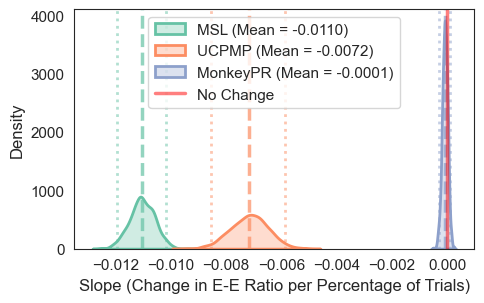

In [34]:
# ---- Density plot (use bootstrap samples for density) ----
plt.figure(figsize=(5.0, 3.2))
plot_order = ["MSL", "UCPMP", "MonkeyPR"]
available = [d for d in plot_order if d in boot_all["dataset"].unique()]
colors = sns.color_palette("Set2", n_colors=len(available))
color_map = dict(zip(available, colors))
for dataset in available:
    boot_df = boot_all[boot_all["dataset"] == dataset]
    if boot_df.empty:
        continue
    mean_slope = boot_df["slope"].mean()
    ci_low, ci_high = np.percentile(boot_df["slope"], [2.5, 97.5])
    sns.kdeplot(
        boot_df["slope"],
        label=f"{dataset} (Mean = {mean_slope:.4f})",
        linewidth=2.0,
        fill=True,
        alpha=0.3,
        color=color_map[dataset],
    )
    plt.axvline(mean_slope, color=color_map[dataset], linestyle="--", alpha=0.7, linewidth=2.5)
    plt.axvline(ci_low, color=color_map[dataset], linestyle=":", alpha=0.5, linewidth=2.0)
    plt.axvline(ci_high, color=color_map[dataset], linestyle=":", alpha=0.5, linewidth=2.0)
plt.axvline(0, color="r", linestyle="-", alpha=0.5, linewidth=2.5, label="No Change")
plt.xlabel("Slope (Change in E-E Ratio per Percentage of Trials)")
plt.ylabel("Density")
# plt.title("E-E Ratio Trial Progression Slopes (Bootstrap n=2000)")
plt.legend()
plt.tight_layout()
# Save to save_path directory
if "save_path" in globals() and isinstance(save_path, str) and len(save_path.strip()) > 0:
    out_dir = Path(save_path)
else:
    out_dir = Path(".")
out_dir.mkdir(parents=True, exist_ok=True)

out_png = out_dir / f"E-E_Slope_distribution_DatasetWise.png"
plt.savefig(out_png, dpi=600, bbox_inches="tight")
print(f"Saved figure to: {out_png}")
plt.show()
